# Recalibration model comparison: `global_median` vs `binned_median` vs `natural_cubic_spline`

Compares the three `fit_correction()` models (`searchops.recalibration`) fit on the
*same* `precursor_ppm`/`precursor_mz` data, across three precursor pools: the full
(unfiltered) run, `top_k_intense`, and `argmax_nms` -- one panel per pool, all three
model curves overlaid on that pool's own scatter.


In [1]:
import os
import subprocess
from pathlib import Path

# Notebook lives 3 levels under the repo root; jupyter/nbconvert default the kernel's cwd
# to the notebook's own directory, so resolve REPO_ROOT and chdir into it *before*
# importing searchops.recalibration below -- that module's dev/inspection block runs a
# cwd-relative file read at import time, which needs cwd == repo root to succeed.
REPO_ROOT = (Path.cwd() / "../../..").resolve()
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from searchops.recalibration import filter_top_psms, fit_correction

FDR = 0.01

# Fixed categorical order (Okabe-Ito, colorblind-safe) -- color follows the model,
# never rank, and stays consistent across every panel below.
MODEL_COLORS = {
    "global_median": "#E69F00",
    "binned_median": "#0072B2",
    "natural_cubic_spline": "#D55E00",
}

MODEL_CONFIGS = {
    "global_median": {"model": "global_median"},
    "binned_median": {"model": "binned_median", "bin_width_da": 10.0},
    "natural_cubic_spline": {"model": "natural_cubic_spline", "bin_width_da": 10.0},
}

PANEL_LABELS = {
    "full": "full (unfiltered)",
    "top_k_intense": "top_5000_intense",
    "random_5000": "random_5000",
    "argmax_nms": "argmax_nms (mz=5/rt=30/mob=0.02)",
    "argmax_nms_tight": "argmax_nms_tight (mz=2.5/rt=15/mob=0.01)",
}


## Resolve result paths via `./nf outputs` (not hardcoded node hashes)

Node hashes change if any upstream config/code changes, so paths are re-resolved from the
job TOMLs each time this notebook runs rather than pasted in as literals.


In [2]:
def nf_outputs(job_toml: str) -> dict[str, dict[str, str]]:
    """Parse `./nf outputs <job_toml>` into {combo_label: {output_name: result_path}}."""
    proc = subprocess.run(
        ["./nf", "outputs", job_toml],
        cwd=REPO_ROOT, capture_output=True, text=True, check=True,
    )
    combos: dict[str, dict[str, str]] = {}
    label = None
    for line in proc.stdout.splitlines():
        if not line.strip():
            continue
        if line.startswith("[") and line.endswith("]"):
            label = line[1:-1]
            combos[label] = {}
            continue
        key, rest = line.split("\t", 1)
        fields = dict(part.split("=", 1) for part in rest.split("\t"))
        combos[label][key] = fields["result"]
    return combos


def find_combo(combos: dict[str, dict[str, str]], suffix: str) -> dict[str, str]:
    """Exact `+<suffix>` match -- a plain substring check would also match
    "argmax_nms" inside "argmax_nms_tight"."""
    matches = [label for label in combos if label.endswith(f"+{suffix}")]
    assert len(matches) == 1, f"expected exactly one combo ending with +{suffix!r}, got {matches}"
    return combos[matches[0]]


# short_test.toml is the true unfiltered population; top_k_intense/argmax_nms are drawn
# from quick_test_10k_recal_grid's 10,000-capped pool.
baseline = nf_outputs("jobs/short_test.toml")["short_test"]
grid = nf_outputs("jobs/full_recal_grid.toml")

paths = {
    "full": REPO_ROOT / baseline["sage_results_tsv"],
    "top_k_intense": REPO_ROOT / find_combo(grid, "top_k_intense")["filtered_sage_results_tsv"],
    "random_5000": REPO_ROOT / find_combo(grid, "random_5000")["filtered_sage_results_tsv"],
    "argmax_nms": REPO_ROOT / find_combo(grid, "argmax_nms")["filtered_sage_results_tsv"],
    "argmax_nms_tight": REPO_ROOT / find_combo(grid, "argmax_nms_tight")["filtered_sage_results_tsv"],
}
paths


{'full': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/short_test/sage_results_tsv/results.sage.tsv'),
 'top_k_intense': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/full_recal_grid__recalibration_precursor_selection+top_k_intense/filtered_sage_results_tsv/results.sage.tsv'),
 'random_5000': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/full_recal_grid__recalibration_precursor_selection+random_5000/filtered_sage_results_tsv/results.sage.tsv'),
 'argmax_nms': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/full_recal_grid__recalibration_precursor_selection+argmax_nms/filtered_sage_results_tsv/results.sage.tsv'),
 'argmax_nms_tight': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/full_recal_grid__recalibration_precursor_selection+argmax_nms_tight/filtered_sage_results_tsv/results.sage.tsv')}

## Load confident PSMs from each pool

`filter_top_psms` (already used by `recalibrate()`) handles the `rank==1 & peptide_q<=fdr`
filter and adds the `precursor_mz` column.


In [3]:
dfs = {panel: filter_top_psms(path, fdr=FDR) for panel, path in paths.items()}
{panel: len(df) for panel, df in dfs.items()}


{'full': 78255,
 'top_k_intense': 3974,
 'random_5000': 519,
 'argmax_nms': 785,
 'argmax_nms_tight': 4044}

## Join `neighbor_cnt` onto `argmax_nms`'s PSMs

`local_intensity_maxima_via_box_nms` now attaches `neighbor_cnt` -- the count of
candidates (including itself) inside each surviving point's own NMS box, previously
discarded -- to its output. That output is exactly what gets submitted to SAGE for the
recalibration branch (`select_recalibration_precursors` writes every column through
unchanged, and SAGE's `scannr` encodes the same `precursor_idx`), so join it back by
`precursor_idx` rather than re-deriving density from the (much sparser, post-search)
PSM set itself.


In [4]:
import re

import mmappet

for panel in ["argmax_nms", "argmax_nms_tight"]:
    precursors_path = REPO_ROOT / find_combo(grid, panel)["recalibration_precursors"]
    precursors = mmappet.open_dataset(precursors_path)[["precursor_idx", "neighbor_cnt"]]

    df = dfs[panel]
    precursor_idx = df["scannr"].str.extract(r"precursor_idx=(\d+)")[0].astype(np.int64)
    df = df.assign(precursor_idx=precursor_idx).merge(precursors, on="precursor_idx", how="left")
    assert df["neighbor_cnt"].notna().all(), f"every {panel} PSM must trace back to a submitted precursor"
    dfs[panel] = df

{panel: dfs[panel]["neighbor_cnt"].describe() for panel in ["argmax_nms", "argmax_nms_tight"]}


{'argmax_nms': count     785.000000
 mean      690.361783
 std       517.559184
 min         3.000000
 25%       231.000000
 50%       588.000000
 75%      1083.000000
 max      2073.000000
 Name: neighbor_cnt, dtype: float64,
 'argmax_nms_tight': count    4044.000000
 mean      108.248022
 std        80.040835
 min         1.000000
 25%        40.000000
 50%        93.000000
 75%       163.000000
 max       374.000000
 Name: neighbor_cnt, dtype: float64}

## Data + all three fitted correction curves, per pool

Each panel overlays the same pool's own `precursor_mz`/`precursor_ppm` scatter with all
three `fit_correction()` models fit on that same data -- so the panels compare pools,
and the curves within each panel compare models.


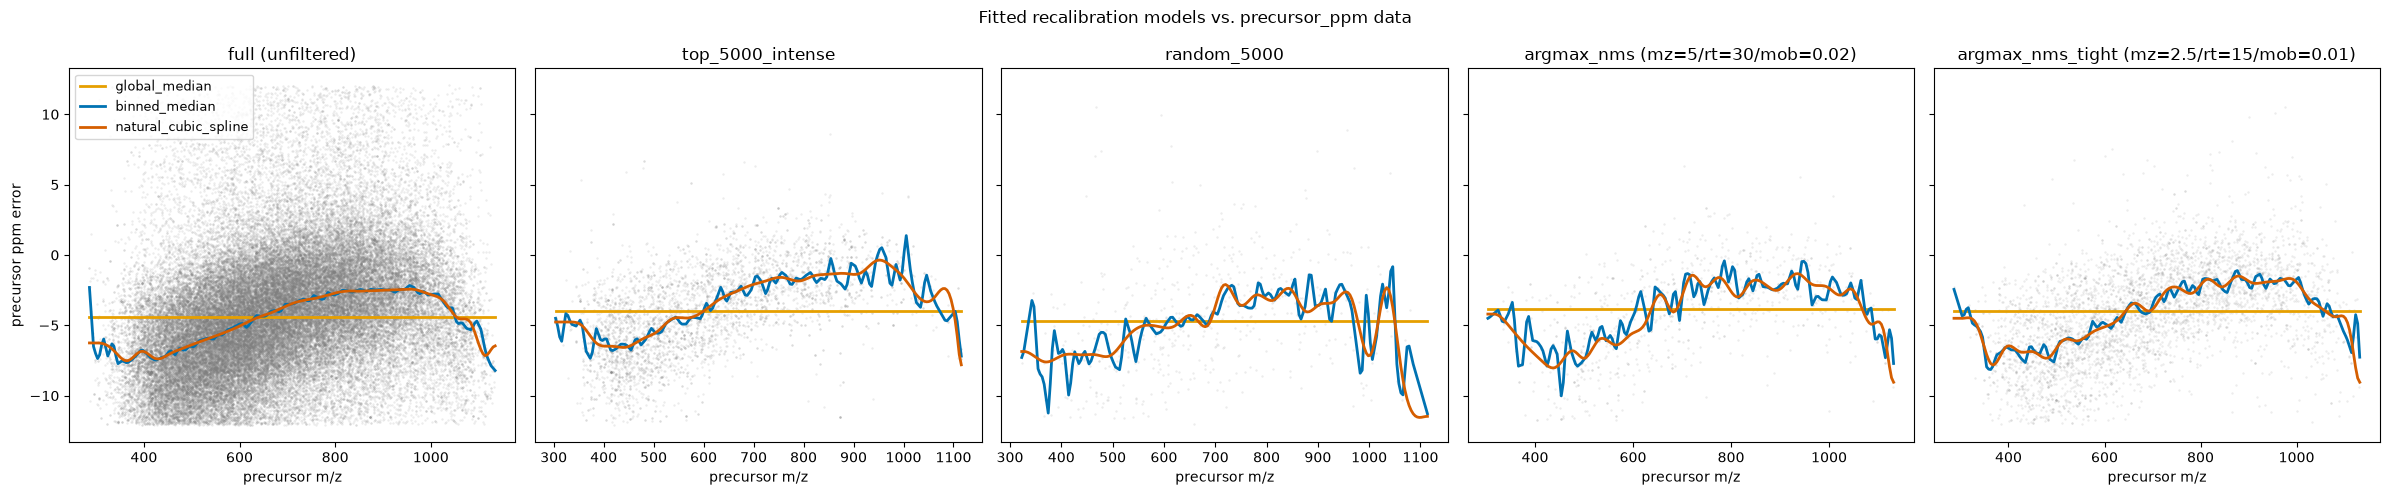

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

for ax, panel in zip(axes, ["full", "top_k_intense", "random_5000", "argmax_nms", "argmax_nms_tight"]):
    df = dfs[panel]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#808080", linewidths=0,
    )

    mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
    for model_name, config in MODEL_CONFIGS.items():
        correction = fit_correction(df, config)
        ax.plot(
            mz_line, correction(mz_line),
            color=MODEL_COLORS[model_name], linewidth=2, label=model_name,
        )

    ax.set_title(PANEL_LABELS[panel])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("Fitted recalibration models vs. precursor_ppm data")
fig.tight_layout()
plt.show()


## `natural_cubic_spline`: `bin_width_da` sweep

The default `bin_width_da=10.0` above produces a visibly wiggly curve -- `fit_correction`'s
only smoothness knob for this model is `bin_width_da` (wider bins -> fewer knots -> less
wiggle), so sweep it directly rather than changing the model.


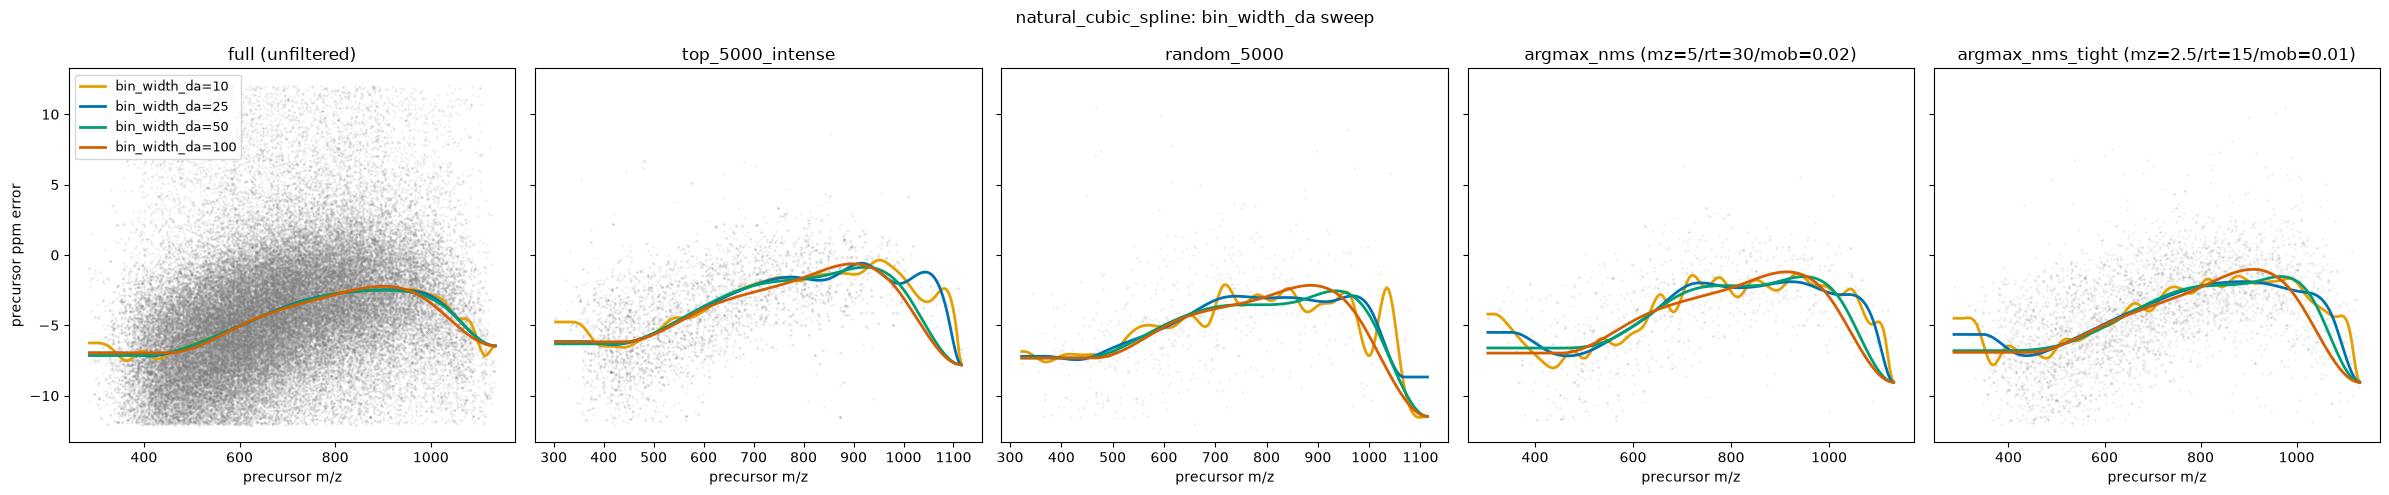

In [6]:
SWEEP_WIDTHS = [10, 25, 50, 100]
SWEEP_COLORS = dict(zip(SWEEP_WIDTHS, ["#E69F00", "#0072B2", "#009E73", "#D55E00"]))

fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

for ax, panel in zip(axes, ["full", "top_k_intense", "random_5000", "argmax_nms", "argmax_nms_tight"]):
    df = dfs[panel]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#808080", linewidths=0,
    )

    mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
    for width in SWEEP_WIDTHS:
        correction = fit_correction(df, {"model": "natural_cubic_spline", "bin_width_da": width})
        ax.plot(
            mz_line, correction(mz_line),
            color=SWEEP_COLORS[width], linewidth=2, label=f"bin_width_da={width}",
        )

    ax.set_title(PANEL_LABELS[panel])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("natural_cubic_spline: bin_width_da sweep")
fig.tight_layout()
plt.show()


## Join MS1 `intensity` onto every pool's PSMs

To let `xgboost` also use the precursor's own MS1 intensity (not just `precursor_mz`),
join it back the same way `neighbor_cnt` was joined for argmax_nms earlier -- by
`precursor_idx` parsed from `scannr`. `full` isn't part of the recalibration branch
(`jobs/short_test.toml` has no `[recalibration]` section, so it runs SAGE once, directly),
so its precursor table is `search_precursors` instead of `recalibration_precursors`; the
other 3 pools reuse the `recalibration_precursors` mmappet already resolved via `grid`.


In [7]:
short_test_outputs = nf_outputs("jobs/short_test.toml")["short_test"]

INTENSITY_SOURCES = {
    "full": REPO_ROOT / short_test_outputs["search_precursors"],
    "top_k_intense": REPO_ROOT / find_combo(grid, "top_k_intense")["recalibration_precursors"],
    "random_5000": REPO_ROOT / find_combo(grid, "random_5000")["recalibration_precursors"],
    "argmax_nms": REPO_ROOT / find_combo(grid, "argmax_nms")["recalibration_precursors"],
    "argmax_nms_tight": REPO_ROOT / find_combo(grid, "argmax_nms_tight")["recalibration_precursors"],
}

for panel, precursors_path in INTENSITY_SOURCES.items():
    precursors = mmappet.open_dataset(precursors_path)[["precursor_idx", "intensity"]]
    df = dfs[panel]
    if "precursor_idx" not in df.columns:
        df = df.assign(
            precursor_idx=df["scannr"].str.extract(r"precursor_idx=(\d+)")[0].astype(np.int64)
        )
    df = df.merge(precursors.rename(columns={"intensity": "ms1_intensity"}), on="precursor_idx", how="left")
    assert df["ms1_intensity"].notna().all(), f"every {panel} PSM must trace back to a submitted precursor"
    dfs[panel] = df

{panel: dfs[panel]["ms1_intensity"].describe() for panel in dfs}


{'full': count    7.825500e+04
 mean     1.778413e+04
 std      4.817807e+04
 min      2.020000e+02
 25%      2.940000e+03
 50%      6.278000e+03
 75%      1.485000e+04
 max      2.492337e+06
 Name: ms1_intensity, dtype: float64,
 'top_k_intense': count    3.974000e+03
 mean     1.546523e+05
 std      1.555911e+05
 min      6.958100e+04
 25%      8.430300e+04
 50%      1.092460e+05
 75%      1.648525e+05
 max      2.492337e+06
 Name: ms1_intensity, dtype: float64,
 'random_5000': count       519.000000
 mean      19000.009634
 std       36691.165354
 min         572.000000
 25%        3293.000000
 50%        7192.000000
 75%       17383.000000
 max      322098.000000
 Name: ms1_intensity, dtype: float64,
 'argmax_nms': count    7.850000e+02
 mean     1.885819e+05
 std      2.723146e+05
 min      1.288000e+03
 25%      4.860400e+04
 50%      1.052890e+05
 75%      2.308800e+05
 max      2.492337e+06
 Name: ms1_intensity, dtype: float64,
 'argmax_nms_tight': count    4.044000e+03
 mean  

## Derivative-penalized smoother and an `xgboost` baseline

Two more candidate models, defined locally here (not added to `searchops/recalibration.py`
-- this is exploratory, not a production model):

- **`fit_derivative_penalized`**: same binned-median nodes as `binned_median`, but the node
  values are smoothed by penalizing the squared first-difference between adjacent nodes
  (a weighted order-1 Whittaker/P-spline smoother, closed-form via a tridiagonal solve --
  since nodes are evenly spaced this is approximately a penalty on the first derivative,
  as opposed to `natural_cubic_spline`'s implicit second-derivative smoothness). `lam`
  trades off fidelity to the raw per-bin medians (`lam=0`) against a flat slope
  (`lam -> inf`) -- picked by eye below, not swept.
- **`fit_xgboost`**: a gradient-boosted tree fit of `precursor_ppm ~ precursor_mz`, no
  smoothness assumption at all, as a nonparametric reference point.


In [8]:
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from xgboost import XGBRegressor


def fit_derivative_penalized(df: pd.DataFrame, config: dict):
    """Binned-median nodes, smoothed by penalizing the first difference between
    adjacent node values (~first derivative, since nodes are evenly spaced) --
    a weighted order-1 Whittaker/P-spline smoother, closed-form via a tridiagonal
    linear solve. `config["lam"]` trades off fidelity to the raw per-bin medians
    (lam=0) against a flat slope (lam -> inf); hand-tune by eye, not swept here.
    """
    mz = df["precursor_mz"].to_numpy()
    ppm = df["precursor_ppm"].to_numpy()
    bin_width = config["bin_width_da"]
    lam = config["lam"]

    bin_idx = np.floor(mz / bin_width).astype(np.int64)
    grouped = (
        pd.DataFrame({"bin": bin_idx, "ppm": ppm})
        .groupby("bin")["ppm"]
        .agg(["median", "count"])
        .sort_index()
    )
    node_mz = (grouped.index.to_numpy() + 0.5) * bin_width
    y = grouped["median"].to_numpy()
    w = grouped["count"].to_numpy().astype(np.float64)

    n = len(y)
    D = diags([-np.ones(n - 1), np.ones(n - 1)], offsets=[0, 1], shape=(n - 1, n))
    A = diags(w) + lam * (D.T @ D)
    f = spsolve(A.tocsc(), w * y)

    return lambda mz: np.interp(mz, node_mz, f)


def fit_xgboost(df: pd.DataFrame, config: dict):
    """Gradient-boosted regression tree fit of precursor_ppm ~ precursor_mz --
    a nonparametric baseline with no smoothness assumption baked in."""
    model = XGBRegressor(
        n_estimators=config.get("n_estimators", 200),
        max_depth=config.get("max_depth", 3),
        learning_rate=config.get("learning_rate", 0.05),
        reg_lambda=config.get("reg_lambda", 1.0),
    )
    mz = df["precursor_mz"].to_numpy().reshape(-1, 1)
    ppm = df["precursor_ppm"].to_numpy()
    model.fit(mz, ppm)
    return lambda mz: model.predict(np.asarray(mz, dtype=np.float64).reshape(-1, 1))


def fit_xgboost_mz_intensity(df: pd.DataFrame, intensity: np.ndarray, config: dict):
    """Gradient-boosted regression tree fit of precursor_ppm ~ precursor_mz + log10(intensity).

    Unlike `fit_correction`'s models and plain `fit_xgboost`, this model's output
    genuinely depends on intensity, so there is no single mz-only curve to evaluate on
    a synthetic line. Returns the fitted model directly -- callers predict on real
    (mz, intensity) pairs and aggregate (e.g. mean per m/z bin via `binned_average`)
    rather than calling it like the other 1-arg correction functions.
    """
    model = XGBRegressor(
        n_estimators=config.get("n_estimators", 200),
        max_depth=config.get("max_depth", 3),
        learning_rate=config.get("learning_rate", 0.05),
        reg_lambda=config.get("reg_lambda", 1.0),
    )
    X = np.column_stack([df["precursor_mz"].to_numpy(), np.log10(intensity)])
    model.fit(X, df["precursor_ppm"].to_numpy())
    return model


def binned_average(mz: np.ndarray, values: np.ndarray, bin_width_da: float):
    """Mean of `values` per `bin_width_da`-wide m/z bin -- used to visualize a model
    whose predictions vary within a bin (e.g. by intensity), averaging that variation
    out to get a curve comparable to the other mz-only models."""
    bin_idx = np.floor(mz / bin_width_da).astype(np.int64)
    grouped = pd.DataFrame({"bin": bin_idx, "value": values}).groupby("bin")["value"].mean().sort_index()
    bin_centers = (grouped.index.to_numpy() + 0.5) * bin_width_da
    return bin_centers, grouped.to_numpy()


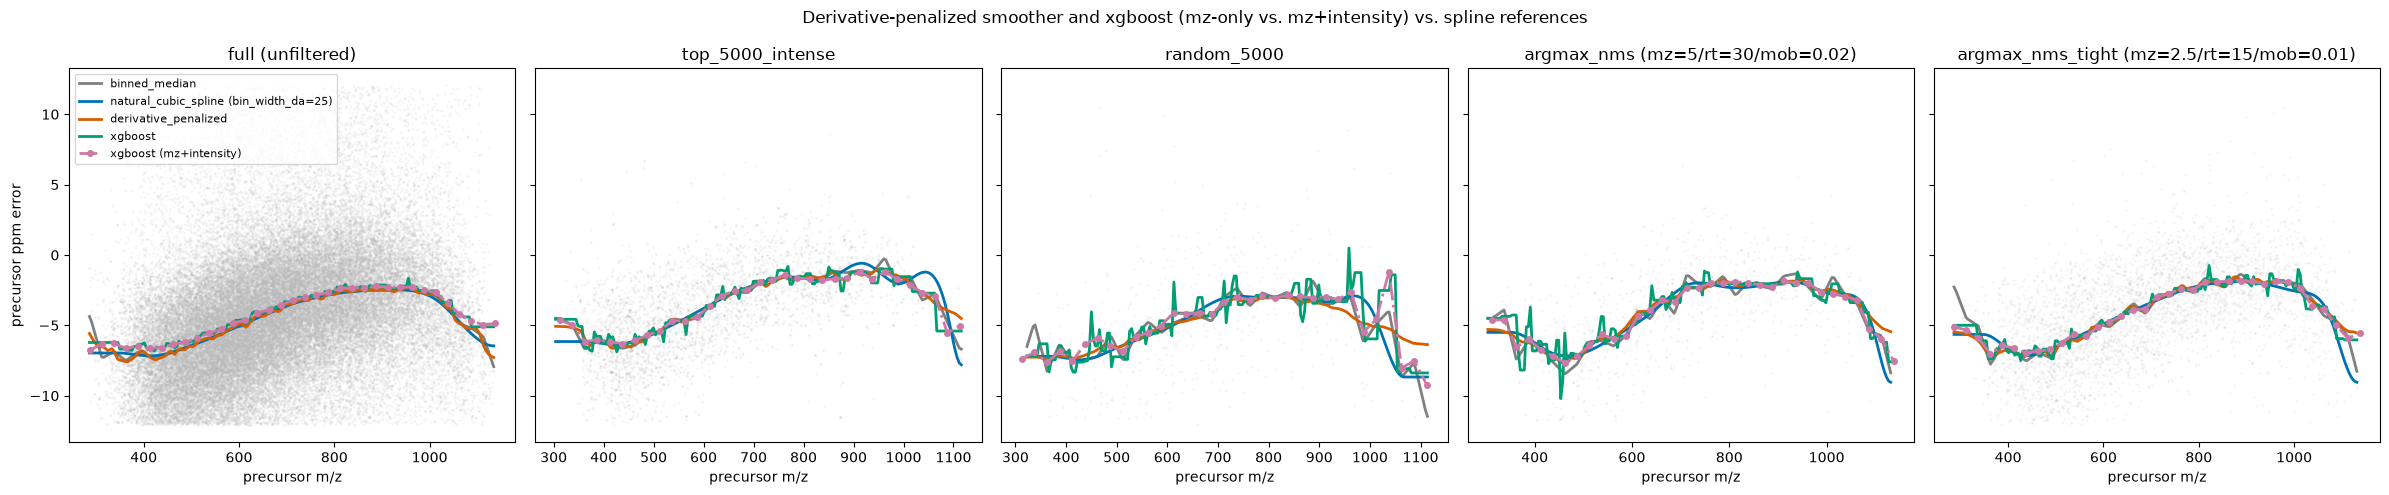

In [9]:
COMPARE_COLORS = {
    "binned_median": "#808080",
    "natural_cubic_spline (bin_width_da=25)": "#0072B2",
    "derivative_penalized": "#D55E00",
    "xgboost": "#009E73",
    "xgboost (mz+intensity)": "#CC79A7",
}

fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

for ax, panel in zip(axes, ["full", "top_k_intense", "random_5000", "argmax_nms", "argmax_nms_tight"]):
    df = dfs[panel]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#bbbbbb", linewidths=0,
    )

    mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
    curves = {
        "binned_median": fit_correction(df, {"model": "binned_median", "bin_width_da": 25.0}),
        "natural_cubic_spline (bin_width_da=25)": fit_correction(
            df, {"model": "natural_cubic_spline", "bin_width_da": 25.0}
        ),
        "derivative_penalized": fit_derivative_penalized(df, {"bin_width_da": 10.0, "lam": 50.0}),
        "xgboost": fit_xgboost(df, {}),
    }
    for name, correction in curves.items():
        ax.plot(mz_line, correction(mz_line), color=COMPARE_COLORS[name], linewidth=2, label=name)

    # xgboost(mz+intensity) can't be evaluated on a synthetic mz_line (it needs a real
    # intensity per point) -- predict on the actual rows and average per m/z bin instead.
    xgb_mz_int = fit_xgboost_mz_intensity(df, df["ms1_intensity"].to_numpy(), {})
    X = np.column_stack([df["precursor_mz"].to_numpy(), np.log10(df["ms1_intensity"].to_numpy())])
    predicted = xgb_mz_int.predict(X)
    bin_centers, bin_avg = binned_average(df["precursor_mz"].to_numpy(), predicted, bin_width_da=25.0)
    ax.plot(
        bin_centers, bin_avg,
        color=COMPARE_COLORS["xgboost (mz+intensity)"], linewidth=2, linestyle="-.",
        marker="o", markersize=4, label="xgboost (mz+intensity)",
    )

    ax.set_title(PANEL_LABELS[panel])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=8, loc="best")
fig.suptitle("Derivative-penalized smoother and xgboost (mz-only vs. mz+intensity) vs. spline references")
fig.tight_layout()
plt.show()


## All 5 models, one panel each, pools overlaid

Transposes the earlier layout: instead of one panel per pool (with models overlaid),
one panel per model category here, each overlaying the 3 pools (`full`,
`top_k_intense`, `argmax_nms`) as curves -- so this reads as "how much do the pools
disagree, for a given model," rather than "how much do the models disagree, for a
given pool." No scatter (3 overlaid pools' raw points would be noisy); curves only.
`binned_median`/`natural_cubic_spline` use `bin_width_da=25.0` (the sweep's middling
pick); `derivative_penalized` uses the same `bin_width_da=10.0, lam=50.0` as before.


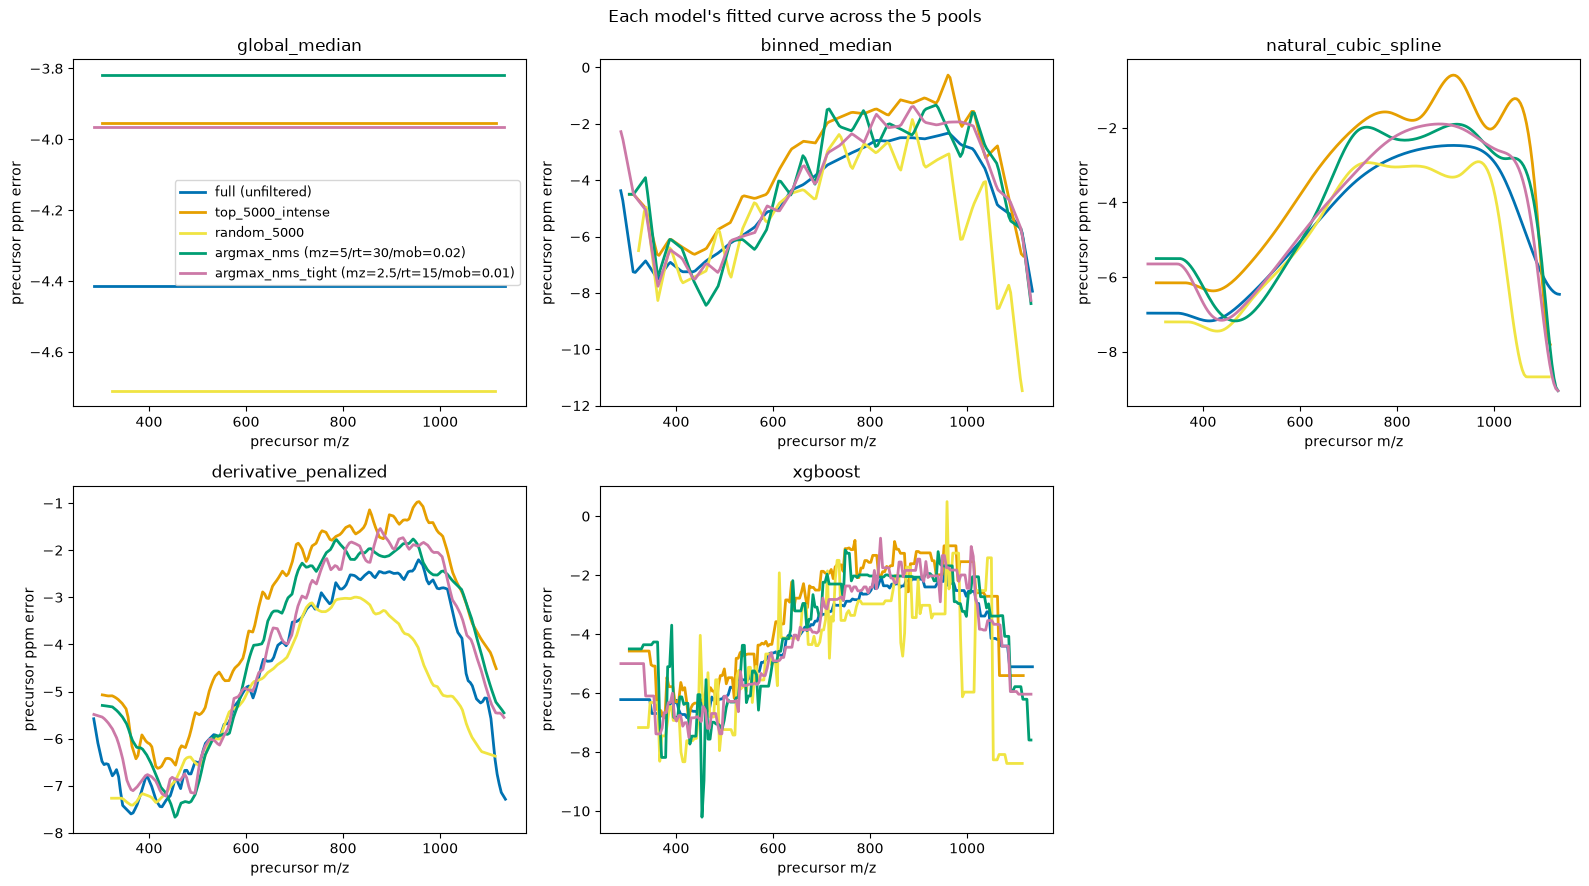

In [10]:
POOL_COLORS = {
    "full": "#0072B2",
    "top_k_intense": "#E69F00",
    "random_5000": "#F0E442",
    "argmax_nms": "#009E73",
    "argmax_nms_tight": "#CC79A7",
}

MODEL_PANELS = {
    "global_median": lambda df: fit_correction(df, {"model": "global_median"}),
    "binned_median": lambda df: fit_correction(df, {"model": "binned_median", "bin_width_da": 25.0}),
    "natural_cubic_spline": lambda df: fit_correction(
        df, {"model": "natural_cubic_spline", "bin_width_da": 25.0}
    ),
    "derivative_penalized": lambda df: fit_derivative_penalized(
        df, {"bin_width_da": 10.0, "lam": 50.0}
    ),
    "xgboost": lambda df: fit_xgboost(df, {}),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (model_name, fit_fn) in zip(axes, MODEL_PANELS.items()):
    for panel in ["full", "top_k_intense", "random_5000", "argmax_nms", "argmax_nms_tight"]:
        df = dfs[panel]
        mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
        correction = fit_fn(df)
        ax.plot(
            mz_line, correction(mz_line),
            color=POOL_COLORS[panel], linewidth=2, label=PANEL_LABELS[panel],
        )
    ax.set_title(model_name)
    ax.set_xlabel("precursor m/z")
    ax.set_ylabel("precursor ppm error")

axes[-1].axis("off")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("Each model's fitted curve across the 5 pools")
fig.tight_layout()
plt.show()


## Unweighted vs. `neighbor_cnt`-weighted fit, default vs. tight radii (argmax_nms)

`argmax_nms` is the only pool with a real density signal (`top_k_intense` is a global
rank cut, `non_overlap`'s grid-cell occupancy isn't captured yet) -- weight each
surviving PSM by how many candidates its own NMS box suppressed, so a survivor that
stood in for a crowded neighborhood counts for more than one that was already
isolated. `fit_correction`'s `weights` argument leaves every other call in this
notebook (and `recalibrate()` itself) untouched -- passing `weights=None` (the
default) reproduces the exact unweighted curves fit earlier.

Also compares the default NMS radii (`mz_radius_da=5.0, rt_radius_s=30.0,
mobility_radius=0.02`) against half those radii (`argmax_nms_tight`, `jobs/full_recal_grid.toml`)
-- smaller neighborhoods mean fewer candidates get suppressed per surviving point, so
more of the underlying cloud survives (730 -> 2235 PSMs here) at the cost of `neighbor_cnt`
itself shrinking (denser boxes now split across more survivors instead of collapsing
into one).


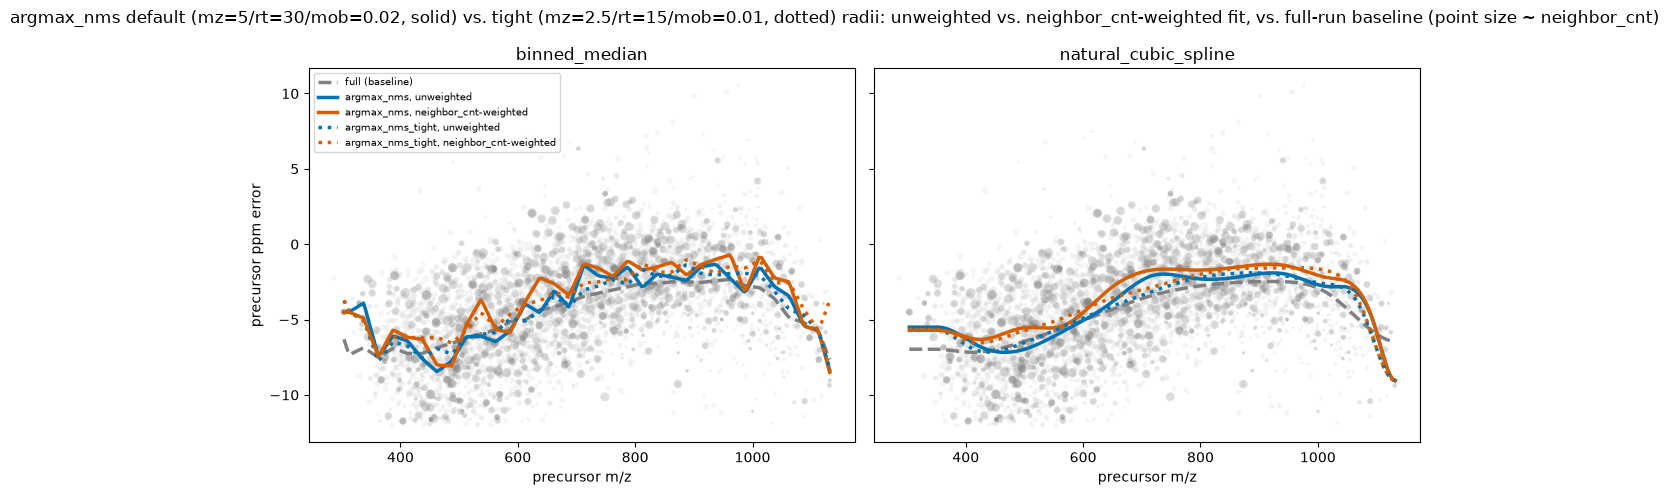

In [11]:
argmax_df = dfs["argmax_nms"]
argmax_tight_df = dfs["argmax_nms_tight"]
full_df_ref = dfs["full"]
argmax_weights = argmax_df["neighbor_cnt"].to_numpy(dtype=np.float64)
argmax_tight_weights = argmax_tight_df["neighbor_cnt"].to_numpy(dtype=np.float64)
mz_line = np.linspace(argmax_df["precursor_mz"].min(), argmax_df["precursor_mz"].max(), 200)

WEIGHT_CONFIGS = {
    "binned_median": {"model": "binned_median", "bin_width_da": 25.0},
    "natural_cubic_spline": {"model": "natural_cubic_spline", "bin_width_da": 25.0},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# sqrt-scaled, capped marker area -- neighbor_cnt spans ~1 to ~2000+ on the uncapped
# full population, so a linear size mapping (or even a big multiplier) produces
# bubbles large enough to visually bury the trend lines; sqrt scaling keeps area
# proportional to neighbor_cnt while staying in a readable size range.
def bubble_size(neighbor_cnt):
    return 3.0 + np.sqrt(neighbor_cnt.to_numpy())

for ax, (model_name, config) in zip(axes, WEIGHT_CONFIGS.items()):
    # tight window is denser (more survivors) -- draw it first, underneath
    ax.scatter(
        argmax_tight_df["precursor_mz"], argmax_tight_df["precursor_ppm"],
        s=bubble_size(argmax_tight_df["neighbor_cnt"]), alpha=0.15, color="#bbbbbb",
        linewidths=0, zorder=1,
    )
    ax.scatter(
        argmax_df["precursor_mz"], argmax_df["precursor_ppm"],
        s=bubble_size(argmax_df["neighbor_cnt"]), alpha=0.25, color="#808080",
        linewidths=0, zorder=2,
    )

    full_baseline = fit_correction(full_df_ref, config)
    unweighted = fit_correction(argmax_df, config)
    weighted = fit_correction(argmax_df, config, weights=argmax_weights)
    tight_unweighted = fit_correction(argmax_tight_df, config)
    tight_weighted = fit_correction(argmax_tight_df, config, weights=argmax_tight_weights)

    ax.plot(
        mz_line, full_baseline(mz_line),
        color="#808080", linewidth=2.5, linestyle="--", label="full (baseline)", zorder=5,
    )
    ax.plot(
        mz_line, unweighted(mz_line),
        color="#0072B2", linewidth=2.5, linestyle="-", label="argmax_nms, unweighted", zorder=5,
    )
    ax.plot(
        mz_line, weighted(mz_line),
        color="#D55E00", linewidth=2.5, linestyle="-", label="argmax_nms, neighbor_cnt-weighted", zorder=5,
    )
    ax.plot(
        mz_line, tight_unweighted(mz_line),
        color="#0072B2", linewidth=2.5, linestyle=":", label="argmax_nms_tight, unweighted", zorder=5,
    )
    ax.plot(
        mz_line, tight_weighted(mz_line),
        color="#D55E00", linewidth=2.5, linestyle=":", label="argmax_nms_tight, neighbor_cnt-weighted", zorder=5,
    )

    ax.set_title(model_name)
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=7, loc="best")
fig.suptitle(
    "argmax_nms default (mz=5/rt=30/mob=0.02, solid) vs. tight (mz=2.5/rt=15/mob=0.01, dotted) "
    "radii: unweighted vs. neighbor_cnt-weighted fit, vs. full-run baseline "
    "(point size ~ neighbor_cnt)"
)
fig.tight_layout()
plt.show()


## Checking the subselection fallacy: does a smaller submitted pool bias FDR-survivors toward cleaner spectra?

`filter_top_psms` keeps only FDR-confident PSMs, and SAGE computes that FDR via
target-decoy competition *within whatever precursor pool got submitted*. A strategy
that only submits 5000 (or 730/2235) precursors competes across a far smaller decoy
population than the full run's ~649k -- if that skews the surviving PSMs toward
cleaner/easier spectra regardless of *which* precursors were submitted, it would
explain why even `random_5000` (an unbiased sample of precursors) still shows an
artificially tight ppm-error cloud, and why `xgboost` -- the most flexible fitter --
looks tightest of all: it would be overfitting an already too-easy subsample.

Compare submitted-vs-surviving counts and SAGE's own PSM-quality scores
(`hyperscore`, `sage_discriminant_score`) across pools: a systematic upward shift
in the smaller pools' surviving PSMs would confirm the competition-size mechanism
rather than anything about the selection criterion itself.


In [12]:
SUBMITTED_COUNTS = {panel: len(mmappet.open_dataset(p)) for panel, p in INTENSITY_SOURCES.items()}
SURVIVING_COUNTS = {panel: len(dfs[panel]) for panel in INTENSITY_SOURCES}

pd.DataFrame({
    "submitted": SUBMITTED_COUNTS,
    "confident_psms": SURVIVING_COUNTS,
}).assign(survival_pct=lambda d: 100 * d["confident_psms"] / d["submitted"])


,submitted,confident_psms,survival_pct
full,649060,78255,12.056667
top_k_intense,5000,3974,79.480000
random_5000,5000,519,10.380000
argmax_nms,1592,785,49.309045
argmax_nms_tight,10101,4044,40.035640


In [13]:
SCORE_COLS = ["hyperscore", "sage_discriminant_score"]

score_summary = pd.DataFrame({
    panel: {
        "n_confident_psms": len(dfs[panel]),
        "hyperscore_median": dfs[panel]["hyperscore"].median(),
        "hyperscore_p10": dfs[panel]["hyperscore"].quantile(0.10),
        "sage_discriminant_score_median": dfs[panel]["sage_discriminant_score"].median(),
        "sage_discriminant_score_p10": dfs[panel]["sage_discriminant_score"].quantile(0.10),
        "precursor_ppm_mad": (dfs[panel]["precursor_ppm"] - dfs[panel]["precursor_ppm"].median()).abs().median(),
    }
    for panel in INTENSITY_SOURCES
}).T
score_summary


,n_confident_psms,hyperscore_median,hyperscore_p10,sage_discriminant_score_median,sage_discriminant_score_p10,precursor_ppm_mad
full,78255.0,29.051280,20.414559,0.735136,0.470282,2.613534
top_k_intense,3974.0,40.622015,27.918034,1.093081,0.901546,2.198508
random_5000,519.0,30.121815,22.156784,0.412056,0.276081,2.469173
argmax_nms,785.0,40.995436,23.838624,0.264594,0.076299,2.284995
argmax_nms_tight,4044.0,34.225168,20.750925,0.856909,0.627838,2.282208


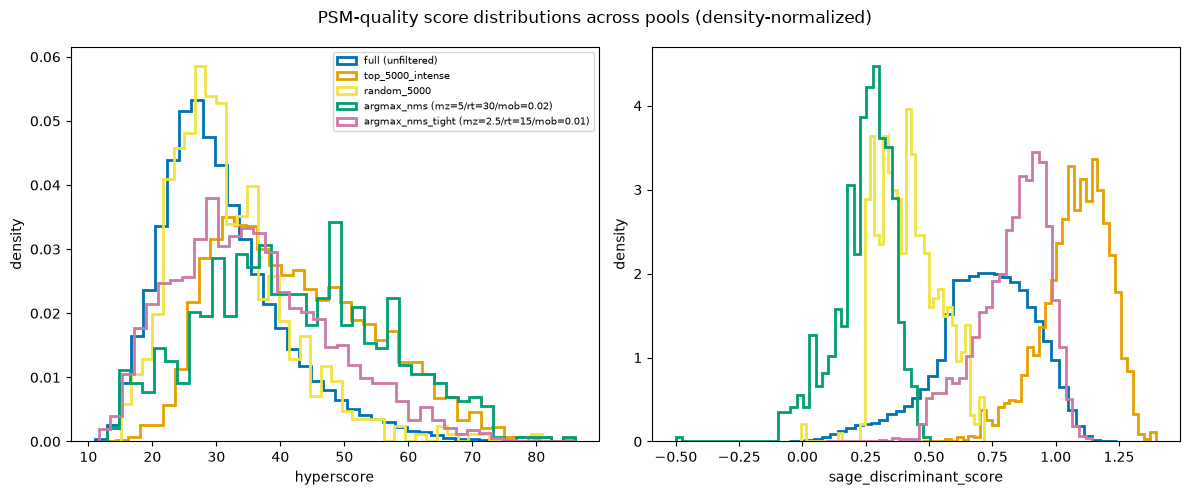

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, SCORE_COLS):
    for panel in INTENSITY_SOURCES:
        df = dfs[panel]
        ax.hist(
            df[col], bins=40, density=True, histtype="step",
            color=POOL_COLORS[panel], linewidth=2, label=PANEL_LABELS[panel],
        )
    ax.set_xlabel(col)
    ax.set_ylabel("density")

axes[0].legend(fontsize=7, loc="best")
fig.suptitle("PSM-quality score distributions across pools (density-normalized)")
fig.tight_layout()
plt.show()


## Does recalibration actually help, in a real full-pipeline run?

Everything above fits correction functions *offline* on selected-precursor subsets
and eyeballs them against `full`'s own raw, uncorrected `precursor_ppm`. That
doesn't confirm the correction, once actually applied inside the real pipeline,
tightens a genuine full production run's ppm-error distribution. `jobs/short_test_recal.toml`
is exactly that real run: same untruncated `data/F9477.d` and uncapped
`[precursor_filters.mkpmsms]` as `jobs/short_test.toml` (this notebook's `full`
pool), but with `[recalibration]` turned on (`top_k_intense` k=5000,
`natural_cubic_spline`) end-to-end -- selects a subset, fits a correction, then
re-searches the *entire* precursor pool with the recalibrated tof2mz/tolerance.
No `[sagepy_rescore]` section is set (nor in any job in this repo), so this is
untouched by any downstream ML rescoring -- purely SAGE's own native output,
pre- vs. post-recalibration.


In [15]:
import json as _json

recal_outputs = nf_outputs("jobs/short_test_recal.toml")["short_test_recal"]

with open(REPO_ROOT / recal_outputs["recalibration_tolerance"]) as _f:
    applied_tolerance = _json.load(_f)
applied_tolerance


{'fragment_tol': {'ppm': [-10.24170447503057, 12.641905177184931]},
 'precursor_tol': {'ppm': [-10.24170447503057, 12.641905177184931]}}

In [16]:
post_correction_df = filter_top_psms(REPO_ROOT / recal_outputs["sage_results_tsv"], fdr=FDR)
pre_correction_df = dfs["full"]

len(pre_correction_df), len(post_correction_df)


(78255, 80971)

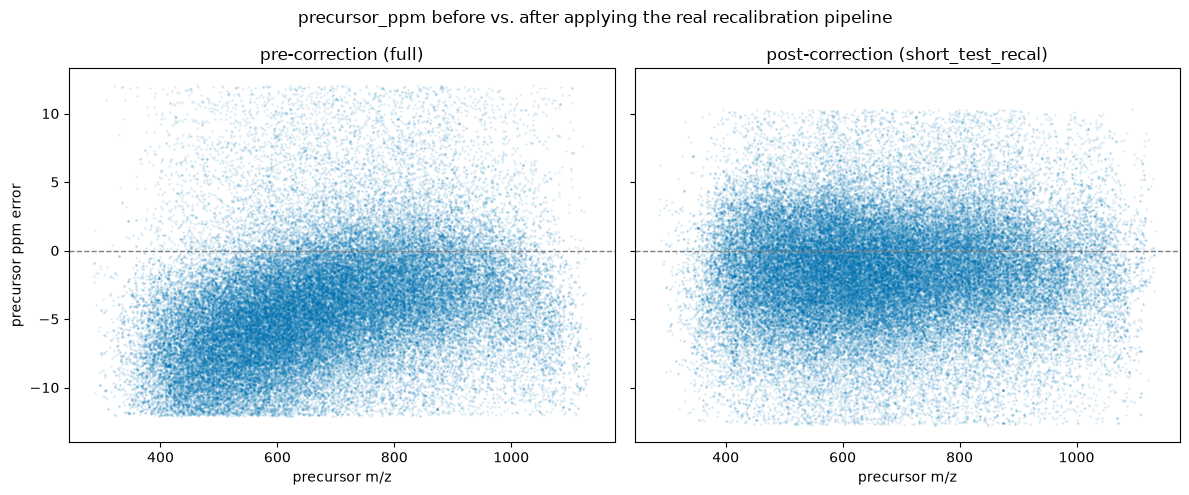

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (label, df) in zip(axes, [("pre-correction (full)", pre_correction_df), ("post-correction (short_test_recal)", post_correction_df)]):
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#0072B2", linewidths=0,
    )
    ax.axhline(0, color="#808080", linewidth=1, linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
fig.suptitle("precursor_ppm before vs. after applying the real recalibration pipeline")
fig.tight_layout()
plt.show()


In [18]:
def ppm_summary(df):
    ppm = df["precursor_ppm"]
    return {
        "n_confident_psms": len(df),
        "median": ppm.median(),
        "mad": (ppm - ppm.median()).abs().median(),
        "iqr": ppm.quantile(0.75) - ppm.quantile(0.25),
        "p1": ppm.quantile(0.01),
        "p99": ppm.quantile(0.99),
    }

pd.DataFrame({
    "pre-correction (full)": ppm_summary(pre_correction_df),
    "post-correction (short_test_recal)": ppm_summary(post_correction_df),
}).T


,n_confident_psms,median,mad,iqr,p1,p99
pre-correction (full),78255.0,-4.412877,2.613534,5.226636,-11.643235,9.548453
post-correction (short_test_recal),80971.0,-1.525093,2.376357,4.761388,-11.357541,8.351979


### PSM/peptide/ion/protein-level counts, pre- vs. post-correction

Already computed by the `sage_summarize` rule (`searchops.sage.summarize_sage()`)
for both jobs -- no rerun needed. "ion" = distinct `(peptide, charge)` pairs;
"psm"/"peptide"/"protein" each filter by their own q-value column
(`spectrum_q`/`peptide_q`/`protein_q`).


In [19]:
level_counts = pd.DataFrame({
    "pre-correction (full)": pd.read_csv(REPO_ROOT / "results/short_test/sage_summary/results.sage.summary.tsv", sep="\t").iloc[0],
    "post-correction (short_test_recal)": pd.read_csv(REPO_ROOT / "results/short_test_recal/sage_summary/results.sage.summary.tsv", sep="\t").iloc[0],
})
level_counts["delta"] = level_counts["post-correction (short_test_recal)"] - level_counts["pre-correction (full)"]
level_counts["delta_pct"] = 100 * level_counts["delta"] / level_counts["pre-correction (full)"]
level_counts


,pre-correction (full),post-correction (short_test_recal),delta,delta_pct
psm_count,78597,81334,2737,3.482321
peptide_count,19048,19358,310,1.627467
ion_count,21669,22101,432,1.993631
protein_count,3917,3925,8,0.204238


### Full 3x4 grid: selection strategy x correction model, real full-pipeline

`jobs/short_test_recal_grid.toml` cross-products 3 precursor-selection strategies
(`top_k_intense`, `random_5000`, `argmax_nms`) with 4 correction models
(`global_median`, `binned_median`, `natural_cubic_spline`, and the new
`xgboost_derivative_penalized` -- xgboost predictions at each `binned_median`-style
node, then smoothed by the same first-derivative Whittaker penalty as the
notebook's earlier `fit_derivative_penalized`, now a real production model in
`searchops.recalibration.fit_correction`) -- 12 real full-pipeline runs, each
searching the *entire* ~649k-precursor pool with its own recalibrated
tof2mz/tolerance. `top_k_intense` x `natural_cubic_spline` (bin_width_da=10) is
the already-established production baseline.


In [20]:
grid_combos = nf_outputs("jobs/short_test_recal_grid.toml")

def combo_label_parts(label):
    # "short_test_recal_grid__recalibration_precursor_selection+X__recalibration+Y"
    parts = label.split("__")
    selection = next(p.split("+", 1)[1] for p in parts if p.startswith("recalibration_precursor_selection+"))
    model = next(p.split("+", 1)[1] for p in parts if p.startswith("recalibration+"))
    return selection, model

grid_rows = []
for label, outputs in grid_combos.items():
    selection, model = combo_label_parts(label)
    combo_df = filter_top_psms(REPO_ROOT / outputs["sage_results_tsv"], fdr=FDR)
    ppm = combo_df["precursor_ppm"]
    level = pd.read_csv(REPO_ROOT / outputs["sage_summary"], sep="\t").iloc[0]
    grid_rows.append({
        "selection": selection,
        "model": model,
        "n_confident_psms": len(combo_df),
        "ppm_median": ppm.median(),
        "ppm_mad": (ppm - ppm.median()).abs().median(),
        "ppm_iqr": ppm.quantile(0.75) - ppm.quantile(0.25),
        "psm_count": level["psm_count"],
        "peptide_count": level["peptide_count"],
        "ion_count": level["ion_count"],
        "protein_count": level["protein_count"],
    })

grid_summary = pd.DataFrame(grid_rows).set_index(["selection", "model"]).sort_index()
grid_summary


n_confident_psms  ppm_median  \
selection     model                                                        
argmax_nms    binned_median                            74188   -0.718114   
              global_median                            75582   -0.944118   
              natural_cubic_spline                     76331   -0.506586   
              xgboost_derivative_penalized             75889   -0.567161   
random_5000   binned_median                            79171   -0.166141   
              global_median                            76697   -0.380061   
              natural_cubic_spline                     76621   -0.272420   
              xgboost_derivative_penalized             80948   -0.337351   
top_k_intense binned_median                            79977   -1.489164   
              global_median                            78000   -0.925055   
              natural_cubic_spline                     80971   -1.525093   
              xgboost_derivative_penalized             79796   -1.462068   

                                             ppm_mad   ppm_iqr  psm_count  \
selection     model                                                         
argmax_nms    binned_median                 2.321917  4.643519      74511   
              global_median                 2.607542  5.234629      75919   
              natural_cubic_spline          2.291599  4.590897      76653   
              xgboost_derivative_penalized  2.273051  4.538246      76207   
random_5000   binned_median                 2.564997  5.156301      79509   
              global_median                 2.703177  5.460475      77025   
              natural_cubic_spline          2.472270  4.973746      76944   
              xgboost_derivative_penalized  2.475484  4.953895      81301   
top_k_intense binned_median                 2.379743  4.778440      80312   
              global_median                 2.692047  5.391842      78350   
              natural_cubic_spline          2.376357  4.761388      81334   
              xgboost_derivative_penalized  2.374731  4.743970      80141   

                                            peptide_count  ion_count  \
selection     model                                                    
argmax_nms    binned_median                         18441      20940   
              global_median                         18603      21155   
              natural_cubic_spline                  18810      21383   
              xgboost_derivative_penalized          18701      21229   
random_5000   binned_median                         18693      21381   
              global_median                         18199      20784   
              natural_cubic_spline                  18197      20768   
              xgboost_derivative_penalized          19337      22030   
top_k_intense binned_median                         19035      21724   
              global_median                         18780      21400   
              natural_cubic_spline                  19358      22101   
              xgboost_derivative_penalized          19004      21668   

                                            protein_count  
selection     model                                        
argmax_nms    binned_median                          3831  
              global_median                          3824  
              natural_cubic_spline                   3892  
              xgboost_derivative_penalized           3845  
random_5000   binned_median                          3855  
              global_median                          3747  
              natural_cubic_spline                   3760  
              xgboost_derivative_penalized           3915  
top_k_intense binned_median                          3870  
              global_median                          3856  
              natural_cubic_spline                   3925  
              xgboost_derivative_penalized           3878

Same table, but ranked by `abs(ppm_median)` (closest-to-zero systematic offset
first) to spot which selection+model combo best removes the systematic bias, and
by `peptide_count` to spot which one recovers the most identifications.


In [21]:
display(grid_summary.sort_values("ppm_median", key=lambda s: s.abs()))
display(grid_summary.sort_values("peptide_count", ascending=False))


n_confident_psms  ppm_median  \
selection     model                                                        
random_5000   binned_median                            79171   -0.166141   
              natural_cubic_spline                     76621   -0.272420   
              xgboost_derivative_penalized             80948   -0.337351   
              global_median                            76697   -0.380061   
argmax_nms    natural_cubic_spline                     76331   -0.506586   
              xgboost_derivative_penalized             75889   -0.567161   
              binned_median                            74188   -0.718114   
top_k_intense global_median                            78000   -0.925055   
argmax_nms    global_median                            75582   -0.944118   
top_k_intense xgboost_derivative_penalized             79796   -1.462068   
              binned_median                            79977   -1.489164   
              natural_cubic_spline                     80971   -1.525093   

                                             ppm_mad   ppm_iqr  psm_count  \
selection     model                                                         
random_5000   binned_median                 2.564997  5.156301      79509   
              natural_cubic_spline          2.472270  4.973746      76944   
              xgboost_derivative_penalized  2.475484  4.953895      81301   
              global_median                 2.703177  5.460475      77025   
argmax_nms    natural_cubic_spline          2.291599  4.590897      76653   
              xgboost_derivative_penalized  2.273051  4.538246      76207   
              binned_median                 2.321917  4.643519      74511   
top_k_intense global_median                 2.692047  5.391842      78350   
argmax_nms    global_median                 2.607542  5.234629      75919   
top_k_intense xgboost_derivative_penalized  2.374731  4.743970      80141   
              binned_median                 2.379743  4.778440      80312   
              natural_cubic_spline          2.376357  4.761388      81334   

                                            peptide_count  ion_count  \
selection     model                                                    
random_5000   binned_median                         18693      21381   
              natural_cubic_spline                  18197      20768   
              xgboost_derivative_penalized          19337      22030   
              global_median                         18199      20784   
argmax_nms    natural_cubic_spline                  18810      21383   
              xgboost_derivative_penalized          18701      21229   
              binned_median                         18441      20940   
top_k_intense global_median                         18780      21400   
argmax_nms    global_median                         18603      21155   
top_k_intense xgboost_derivative_penalized          19004      21668   
              binned_median                         19035      21724   
              natural_cubic_spline                  19358      22101   

                                            protein_count  
selection     model                                        
random_5000   binned_median                          3855  
              natural_cubic_spline                   3760  
              xgboost_derivative_penalized           3915  
              global_median                          3747  
argmax_nms    natural_cubic_spline                   3892  
              xgboost_derivative_penalized           3845  
              binned_median                          3831  
top_k_intense global_median                          3856  
argmax_nms    global_median                          3824  
top_k_intense xgboost_derivative_penalized           3878  
              binned_median                          3870  
              natural_cubic_spline                   3925

n_confident_psms  ppm_median  \
selection     model                                                        
top_k_intense natural_cubic_spline                     80971   -1.525093   
random_5000   xgboost_derivative_penalized             80948   -0.337351   
top_k_intense binned_median                            79977   -1.489164   
              xgboost_derivative_penalized             79796   -1.462068   
argmax_nms    natural_cubic_spline                     76331   -0.506586   
top_k_intense global_median                            78000   -0.925055   
argmax_nms    xgboost_derivative_penalized             75889   -0.567161   
random_5000   binned_median                            79171   -0.166141   
argmax_nms    global_median                            75582   -0.944118   
              binned_median                            74188   -0.718114   
random_5000   global_median                            76697   -0.380061   
              natural_cubic_spline                     76621   -0.272420   

                                             ppm_mad   ppm_iqr  psm_count  \
selection     model                                                         
top_k_intense natural_cubic_spline          2.376357  4.761388      81334   
random_5000   xgboost_derivative_penalized  2.475484  4.953895      81301   
top_k_intense binned_median                 2.379743  4.778440      80312   
              xgboost_derivative_penalized  2.374731  4.743970      80141   
argmax_nms    natural_cubic_spline          2.291599  4.590897      76653   
top_k_intense global_median                 2.692047  5.391842      78350   
argmax_nms    xgboost_derivative_penalized  2.273051  4.538246      76207   
random_5000   binned_median                 2.564997  5.156301      79509   
argmax_nms    global_median                 2.607542  5.234629      75919   
              binned_median                 2.321917  4.643519      74511   
random_5000   global_median                 2.703177  5.460475      77025   
              natural_cubic_spline          2.472270  4.973746      76944   

                                            peptide_count  ion_count  \
selection     model                                                    
top_k_intense natural_cubic_spline                  19358      22101   
random_5000   xgboost_derivative_penalized          19337      22030   
top_k_intense binned_median                         19035      21724   
              xgboost_derivative_penalized          19004      21668   
argmax_nms    natural_cubic_spline                  18810      21383   
top_k_intense global_median                         18780      21400   
argmax_nms    xgboost_derivative_penalized          18701      21229   
random_5000   binned_median                         18693      21381   
argmax_nms    global_median                         18603      21155   
              binned_median                         18441      20940   
random_5000   global_median                         18199      20784   
              natural_cubic_spline                  18197      20768   

                                            protein_count  
selection     model                                        
top_k_intense natural_cubic_spline                   3925  
random_5000   xgboost_derivative_penalized           3915  
top_k_intense binned_median                          3870  
              xgboost_derivative_penalized           3878  
argmax_nms    natural_cubic_spline                   3892  
top_k_intense global_median                          3856  
argmax_nms    xgboost_derivative_penalized           3845  
random_5000   binned_median                          3855  
argmax_nms    global_median                          3824  
              binned_median                          3831  
random_5000   global_median                          3747  
              natural_cubic_spline                   3760